In [ ]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# PyTorch (for later)
import torch
import torch.nn as nn

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

!pip install xgboost

**Upload Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving bike+sharing+dataset.zip to bike+sharing+dataset.zip


**UNZIP THE FILE**

In [ ]:
import zipfile
import os

zip_file = "bike+sharing+dataset.zip"  # change name if needed

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("data")

os.listdir("data")


['day.csv', 'hour.csv', 'Readme.txt']

***Load Dataset***

In [ ]:
df = pd.read_csv("data/hour.csv")   # change path if needed

In [ ]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [ ]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


Handling date and sort

In [ ]:
df['dteday'] = pd.to_datetime(df['dteday'])
df = df.sort_values(['dteday', 'hr'])
df = df.reset_index(drop=True)

Feature Selectionn

In [ ]:
features = ['temp', 'hum', 'windspeed', 'cnt']
df = df[features]

Normalize data

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

Creating sequence function now

In [ ]:
def create_sequences(data, seq_length=24):
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][-1])  # predict 'cnt'

    return np.array(X), np.array(y)

In [ ]:
#create sequences
X, y = create_sequences(scaled_data, seq_length=24)

Train test split

In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
#checking shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (13884, 24, 4)
y_train shape: (13884,)


**Evaluation Function**

In [ ]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

In [ ]:
#Lets flatten the sequence from 3d to 2d for ml models
# Flatten sequences for ML models
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(X_train_flat.shape)

(13884, 96)


ML models

In [ ]:
#Baseline models provide a benchmark. If deep learning models don’t outperform them, their added complexity isn’t justified.

**Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_flat, y_train)

lr_preds = lr_model.predict(X_test_flat)

In [ ]:
#evaluating linear regression models

In [ ]:
mae, rmse, r2 = evaluate_model(y_test, lr_preds)

print("Linear Regression:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Linear Regression:
MAE: 0.3022171845556108
RMSE: 0.4424789362021744
R2: 0.8676561403870928


**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_flat, y_train)

rf_preds = rf_model.predict(X_test_flat)

In [ ]:
#evaluating rf
mae, rmse, r2 = evaluate_model(y_test, rf_preds)

print("\nRandom Forest:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


Random Forest:
MAE: 0.1922099301335053
RMSE: 0.3204763078810306
R2: 0.9305758692765296


**XG BOOST**

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6
)

xgb_model.fit(X_train_flat, y_train)

xgb_preds = xgb_model.predict(X_test_flat)

In [ ]:
#evaluating xg boost
mae, rmse, r2 = evaluate_model(y_test, xgb_preds)

print("\nXGBoost:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


XGBoost:
MAE: 0.18310967128007877
RMSE: 0.29452550775531133
R2: 0.9413639886656402


In [ ]:
results = {}

results["Linear"] = evaluate_model(y_test, lr_preds)
results["Random Forest"] = evaluate_model(y_test, rf_preds)
results["XGBoost"] = evaluate_model(y_test, xgb_preds)

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results, index=["MAE", "RMSE", "R2"]).T
print(results_df)

                    MAE      RMSE        R2
Linear         0.302217  0.442479  0.867656
Random Forest  0.192210  0.320476  0.930576
XGBoost        0.183110  0.294526  0.941364


In [ ]:
def inverse_transform(y_scaled, scaler, feature_index=-1):
    dummy = np.zeros((len(y_scaled), scaler.mean_.shape[0]))
    dummy[:, feature_index] = y_scaled
    return scaler.inverse_transform(dummy)[:, feature_index]

In [ ]:
y_test_inv = inverse_transform(y_test, scaler)

lr_preds_inv = inverse_transform(lr_preds, scaler)
rf_preds_inv = inverse_transform(rf_preds, scaler)
xgb_preds_inv = inverse_transform(xgb_preds, scaler)

In [ ]:
results_real = {}

results_real["Linear"] = evaluate_model(y_test_inv, lr_preds_inv)
results_real["Random Forest"] = evaluate_model(y_test_inv, rf_preds_inv)
results_real["XGBoost"] = evaluate_model(y_test_inv, xgb_preds_inv)

results_real_df = pd.DataFrame(results_real, index=["MAE", "RMSE", "R2"]).T
print(results_real_df)

                     MAE       RMSE        R2
Linear         54.816872  80.257883  0.867656
Random Forest  34.863495  58.128756  0.930576
XGBoost        33.212868  53.421738  0.941364


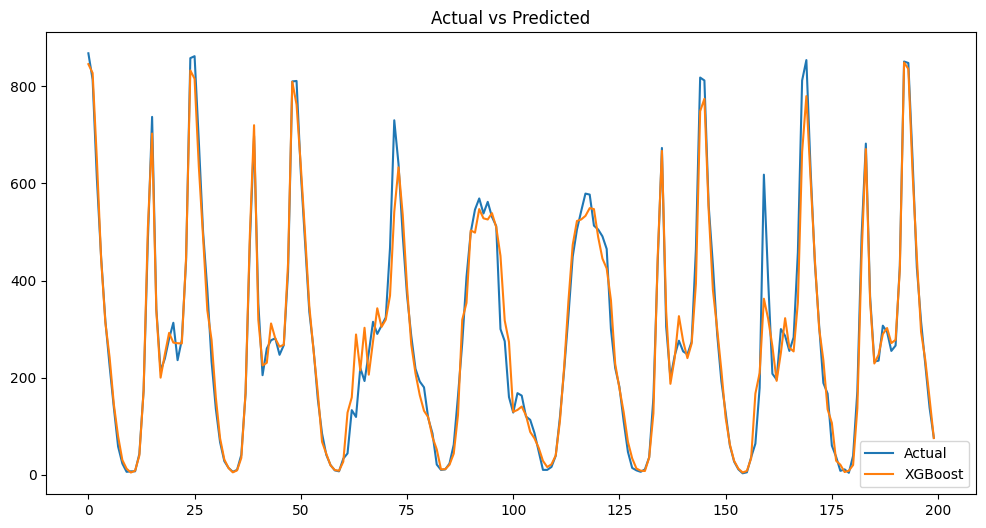

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test_inv[:200], label="Actual")
plt.plot(xgb_preds_inv[:200], label="XGBoost")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

Lets begin DNN

In [ ]:
X_train_flat
X_test_flat

array([[ 1.67754794, -1.12597977, -1.55388851, ...,  0.1698654 ,
         0.76430366,  1.40882985],
       [ 1.67754794, -1.12597977, -0.45609864, ..., -0.03746983,
        -0.45609864,  3.74091966],
       [ 1.46981032, -0.19297125,  0.0318988 , ..., -0.03746983,
        -0.21169121,  3.44320606],
       ...,
       [-1.54238521, -0.6076417 , -0.21169121, ..., -0.14113744,
        -0.21169121, -0.55387457],
       [-1.54238521, -0.40030647,  0.0318988 , ..., -0.14113744,
        -0.21169121, -0.54836135],
       [-1.54238521, -0.6076417 ,  0.27630622, ..., -0.34847267,
        -0.45609864, -0.70824458]])

In [ ]:
#convert to pytorch tensors
X_train_tensor = torch.tensor(X_train_flat, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_flat, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [ ]:
class DNNModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
input_size = X_train_tensor.shape[1]

dnn_model = DNNModel(input_size)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(dnn_model.parameters(), lr=0.001)

In [ ]:
epochs = 20

for epoch in range(epochs):
    dnn_model.train()

    outputs = dnn_model(X_train_tensor).squeeze()
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 5, Loss: 0.7691
Epoch 10, Loss: 0.6284
Epoch 15, Loss: 0.4610
Epoch 20, Loss: 0.3816


In [ ]:
#prediction

In [ ]:
dnn_model.eval()

with torch.no_grad():
    dnn_preds = dnn_model(X_test_tensor).squeeze().numpy()

In [ ]:
mae, rmse, r2 = evaluate_model(y_test, dnn_preds)

print("DNN Results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

DNN Results:
MAE: 0.5513331619742803
RMSE: 0.8196016428370902
R2: 0.5459285106803302


In [ ]:
dnn_preds_inv = inverse_transform(dnn_preds, scaler)

mae, rmse, r2 = evaluate_model(y_test_inv, dnn_preds_inv)

print("\nDNN (Real Values):")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


DNN (Real Values):
MAE: 100.00212132953827
RMSE: 148.66129698308828
R2: 0.5459285106803302


In [ ]:
results_real["DNN"] = evaluate_model(y_test_inv, dnn_preds_inv)

results_real_df = pd.DataFrame(results_real, index=["MAE", "RMSE", "R2"]).T
print(results_real_df)

                      MAE        RMSE        R2
Linear          54.816872   80.257883  0.867656
Random Forest   34.863495   58.128756  0.930576
XGBoost         33.212868   53.421738  0.941364
DNN            100.002121  148.661297  0.545929


In [ ]:
#DNN failed to outperform XGBoost because it does not explicitly capture temporal dependencies, unlike sequence models such as LSTM.

In [ ]:
#now lets convert to tesors (sequence data)
X_train_seq = torch.tensor(X_train, dtype=torch.float32)
y_train_seq = torch.tensor(y_train, dtype=torch.float32)

X_test_seq = torch.tensor(X_test, dtype=torch.float32)
y_test_seq = torch.tensor(y_test, dtype=torch.float32)

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)

        # Take last timestep
        out = out[:, -1, :]

        out = self.fc(out)
        return out

In [ ]:
input_size = X_train.shape[2]

lstm_model = LSTMModel(input_size)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

In [ ]:
epochs = 20

for epoch in range(epochs):
    lstm_model.train()

    outputs = lstm_model(X_train_seq).squeeze()
    loss = criterion(outputs, y_train_seq)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 5, Loss: 0.8317
Epoch 10, Loss: 0.7756
Epoch 15, Loss: 0.7212
Epoch 20, Loss: 0.6710


In [ ]:
lstm_model.eval()

with torch.no_grad():
    lstm_preds = lstm_model(X_test_seq).squeeze().numpy()

In [ ]:
mae, rmse, r2 = evaluate_model(y_test, lstm_preds)

print("LSTM Results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

LSTM Results:
MAE: 0.8524777230001703
RMSE: 1.1711619014387058
R2: 0.0728447420525914


In [ ]:
lstm_preds_inv = inverse_transform(lstm_preds, scaler)

mae, rmse, r2 = evaluate_model(y_test_inv, lstm_preds_inv)

print("\nLSTM (Real Values):")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


LSTM (Real Values):
MAE: 154.62443866231368
RMSE: 212.4281335532467
R2: 0.07284474205259117


In [ ]:
results_real["LSTM"] = evaluate_model(y_test_inv, lstm_preds_inv)

results_real_df = pd.DataFrame(results_real, index=["MAE", "RMSE", "R2"]).T
print(results_real_df)

                      MAE        RMSE        R2
Linear          54.816872   80.257883  0.867656
Random Forest   34.863495   58.128756  0.930576
XGBoost         33.212868   53.421738  0.941364
DNN            100.002121  148.661297  0.545929
LSTM           154.624439  212.428134  0.072845


“Despite using sequence models like LSTM, tree-based models such as XGBoost significantly outperformed deep learning models. This indicates that the dataset behaves more like structured tabular data rather than requiring complex temporal modeling.”

lets imrovise with better features and see if lstm works better

In [ ]:
# Load dataset again (fresh copy)
df_new = pd.read_csv("data/hour.csv")

# Convert date column to datetime
df_new['dteday'] = pd.to_datetime(df_new['dteday'])

# Sort data by time (VERY IMPORTANT for time series)
df_new = df_new.sort_values(['dteday', 'hr'])

# Reset index after sorting
df_new = df_new.reset_index(drop=True)

In [ ]:
# Selecting more informative features (adding time awareness)
features = ['temp', 'hum', 'windspeed', 'hr', 'workingday', 'cnt']

# Keep only selected columns
df_new = df_new[features]

In [ ]:
# Scale data (important for neural networks)
scaler_new = StandardScaler()

# Fit and transform data
scaled_data_new = scaler_new.fit_transform(df_new)

In [ ]:
# Create sequences of length 48 (2 days context)
X_new, y_new = create_sequences(scaled_data_new, seq_length=48)

In [ ]:
# Split data (80% train, 20% test)
split = int(0.8 * len(X_new))

X_train_new, X_test_new = X_new[:split], X_new[split:]
y_train_new, y_test_new = y_new[:split], y_new[split:]

In [ ]:
# Convert numpy arrays to PyTorch tensors
X_train_new = torch.tensor(X_train_new, dtype=torch.float32)
y_train_new = torch.tensor(y_train_new, dtype=torch.float32)

X_test_new = torch.tensor(X_test_new, dtype=torch.float32)
y_test_new = torch.tensor(y_test_new, dtype=torch.float32)

In [ ]:
#keping a copy of df
df_original = pd.read_csv("data/hour.csv")
df = df_original.copy()

In [ ]:
class ImprovedLSTM(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

In [ ]:
input_size = X_train_new.shape[2]

lstm_improved = ImprovedLSTM(input_size)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_improved.parameters(), lr=0.001)

In [ ]:
epochs = 50

for epoch in range(epochs):
    lstm_improved.train()

    outputs = lstm_improved(X_train_new).squeeze()
    loss = criterion(outputs, y_train_new)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 0.6534
Epoch 20, Loss: 0.4408
Epoch 30, Loss: 0.3772
Epoch 40, Loss: 0.3338
Epoch 50, Loss: 0.2894


In [ ]:
lstm_improved.eval()

with torch.no_grad():
    lstm_improved_preds = lstm_improved(X_test_new).squeeze().numpy()

In [ ]:
y_test_new_inv = inverse_transform(y_test_new.numpy(), scaler_new)

lstm_improved_preds_inv = inverse_transform(lstm_improved_preds, scaler_new)

In [ ]:
mae, rmse, r2 = evaluate_model(y_test_new_inv, lstm_improved_preds_inv)

print("Improved LSTM:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Improved LSTM:
MAE: 86.06453017913924
RMSE: 134.27562306245636
R2: 0.6280577290364433


In [ ]:
results_real["LSTM_improved"] = evaluate_model(y_test_new_inv, lstm_improved_preds_inv)

results_real_df = pd.DataFrame(results_real, index=["MAE", "RMSE", "R2"]).T
print(results_real_df)

                      MAE        RMSE        R2
Linear          54.816872   80.257883  0.867656
Random Forest   34.863495   58.128756  0.930576
XGBoost         33.212868   53.421738  0.941364
DNN            100.002121  148.661297  0.545929
LSTM           154.624439  212.428134  0.072845
LSTM_improved   86.064530  134.275623  0.628058
